## *Note: You should be able to use this in both Colab and locally on your system, you don't need to configure the google drive thing with colab*

# COE 592

##  ASSIGNMENT 1


**Description:**

  In this hands-on assignment, you will apply the concepts of feature detection, description and matching methods using OpenCV2 library, and re-assemble an image's slices to match the original image's snapshot

**Deliverables**

  * Completed version of this notebook, renamed to `COE592-Assg1-<Student1_ID>-<Student2_ID>.ipynb`
  * A short report following the below outline:
    * Problem Statement
    * Solution Design and Methodology
      * Describe your proposed solution using a flowchart and psuedocode
    * Experiments and Results
      * Try your solution on some sample images, and include the snapshots of intermediate results, the final re-assembled image, and similarity scores
      * Refer to the hands-on tutorial to see how to implement matching and to show matching results
    * Team details: Names and IDs of the team
  * The original images you used in your work
  

**Submission Instructions:**

Please submit all the deliverables on Blackboard (as individual files and not as a zip/rar archive)


**Credits:**

Prepared by Dr. Abdul Jabbar Siddiqui


In [15]:
!pip install requests

In [16]:
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
import requests

# from google.colab.patches import cv2_imshow

In [17]:
# to mount your google drive (requires Google log in)
# Alternatively, use the "Mount Drive" button from the "Files" tab on the left menu bars
# from google.colab import drive
# drive.mount('/drive')

In [18]:
# Copy and save path to your images directory in mypath
# mypath = '/content/drive/MyDrive/COE595/colab-teaching/'

# Load Images

In [19]:

# Read the larger scene image in which you want to find the query_img object in scene_img
# scene_img = cv2.imread(mypath+'/T3_drone.jpg')
img_link = "https://raw.githubusercontent.com/officialar33b/COE-512-Ass1/main/drone.jpg"

scene_img = cv2.imdecode(
    np.frombuffer(requests.get(img_link).content, np.uint8), 
    cv2.IMREAD_COLOR
)

In [20]:
print(scene_img is None)

False


# Slice and Shuffle Scene Image

In [21]:
# Convert images to grayscale (recommended for ease of using opencv feature descriptors like SIFT, ORB, SURF, etc.)

scene_img_bw = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)


# Function to take a scene_img and split it into multiple slices, returns a shuffled list of slices
def slice_and_shuffle(inimg, doShuffle=True):
  M = inimg.shape[0] // 5
  N = inimg.shape[1] // 5
  # M=5, N=5, to make 25 tiles from a given inimg

  tiles = [inimg[x:x+M,y:y+N] for x in range(0,inimg.shape[0],M) for y in range(0,inimg.shape[1],N)]

  random.shuffle(tiles)

  return tiles

slices_list = slice_and_shuffle(scene_img_bw) # You cannot manipulate this list, but you may manipulate scene_img_bw if needed

### Display Original Image

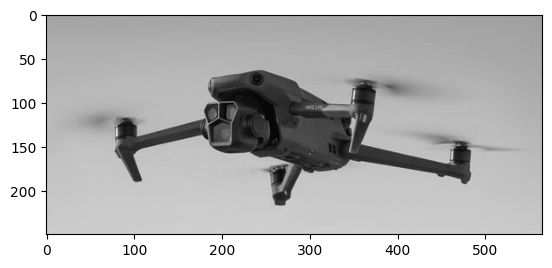

In [22]:
scene_img_bw = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)
plt.imshow(scene_img_bw, cmap='gray')

### Sharpening the Image!?

In [23]:
# scene_img_bw = np.float32(scene_img_bw)/255.
# # sharpening filter
# N = 3
# g = -np.ones((N,N))/(N**2)
# g[(N-1)//2,(N-1)//2] += 2

# scene_img_bw = cv2.filter2D(scene_img_bw, -1, g)
# scene_img_bw = np.clip(scene_img_bw * 255.0, 0, 255).astype(np.uint8)
# plt.imshow(np.clip(scene_img_bw), cmap='gray')

# Tasks to do:
  * Complete the function `reassemble_slices(...)`: using feature detection and matching, re-assemble the slices in `slices_list` to produce the `reassembled_img`
    
    * Hint: select an appropriate feature detector/descriptor and use feature matching to match each slice with the respective region in `scene_img_bw`
    * Note:
      * your solution must not be based on prior knowledge of the slicing sequence or shuffling order. The re-assembling should be based on matching
      * Your solution must have a verification step to deal with "confused" matches and correct those
      * Your solution must not be specific to one image, it should be generic enough to work with different images



In [24]:
# YOUR TASK TO DO

def reassemble_slices(slist = slices_list, orig_img = scene_img_bw):

  # Your code here...

  # ## SIFT Implementation
  # reassembled_img = np.zeros_like(orig_img) # dummy init.

  # ## 5x5 grid.
  # M = orig_img.shape[0] // 5
  # N = orig_img.shape[1] // 5

  # ## Instatiate SIFT detector
  # # sift = cv2.SIFT_create(nfeatures=1000)
  # sift = cv2.SIFT_create(nfeatures=1000, 
  # contrastThreshold=0.01, 
  # edgeThreshold=10, 
  # sigma=1.6)
  # scene_kp, scene_des = sift.detectAndCompute(orig_img, None)

  # ## Brute Force Matcher
  # # matcher = cv2.BFMatcher()

  # ## Using Tuned FLANN Matcher
  # index_params = dict(algorithm=1, trees=10)
  # search_params = dict(checks=100)
  # matcher = cv2.FlannBasedMatcher(index_params, search_params)


  # # Hint: you may use each slice as a query_img
  # for query_img in slist:
  #   query_kp, query_des = sift.detectAndCompute(query_img, None)
  #   if query_des is None or len(query_des) <2:
  #     continue

  #   matches = matcher.knnMatch(query_des, scene_des, k=2)

  #   good_matches = list()
  #   for m, n in matches:
  #     if m.distance < .75 * n.distance:
  #       good_matches.append(m)

  #   if len(good_matches) <2:
  #     continue

  #   query_pts = np.float32([query_kp[m.queryIdx].pt for m in good_matches])
  #   scene_pts = np.float32([scene_kp[m.trainIdx].pt for m in good_matches])

  #   offsets = scene_pts - query_pts
  #   median_x = np.median(offsets[:, 0])
  #   median_y = np.median(offsets[:, 1])

  #   start_col = int(round(median_x /N)*N)
  #   start_row = int(round(median_y /M)*M)

  #   # Now make the image.
  #   if 0 <= start_row < orig_img.shape[0] and 0 <= start_col < orig_img.shape[1]:
  #     reassembled_img[start_row:start_row+M, start_col:start_col+N] = query_img

  

  # SIFT + Cross-Correlation Implementation
    # reassembled_img = np.zeros_like(orig_img) # dummy init.
    reassembled_img = np.zeros(orig_img.shape, dtype=np.uint8)
    rows, cols = 5,5
    M, N = orig_img.shape[0] // rows, orig_img.shape[1] // cols


  
    # Extract SIFT features for the target original scene
    # 1. Detect SIFT keypoints on the original scene image ONCE
    sift = cv2.SIFT_create(
        nfeatures=20000, 
        contrastThreshold=0.001,  # Picks up low-contrast features in smooth regions
        edgeThreshold=30
    )
    
    # Detect SIFT keypoints on original scene image ONCE
    scene_kp, scene_des = sift.detectAndCompute(orig_img, None)
    matcher = cv2.BFMatcher()
    
    # Track occupied grid slots to maintain 1-to-1 placement
    occupied = np.zeros((rows, cols), dtype=bool)
    
    for tile in slist:
        tile_kp, tile_des = sift.detectAndCompute(tile, None)
        
        # Skip tile if no descriptors are found
        if tile_des is None or len(tile_des) < 2:
            continue
            
        # Match slice descriptors against scene descriptors
        matches = matcher.knnMatch(tile_des, scene_des, k=2)
        
        # Apply Lowe's Ratio Test
        good_matches = []
        for m, n in matches:
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)
                
        if len(good_matches) < 2:
            continue
            
        # Extract matching point coordinates
        pts_tile = np.float32([tile_kp[m.queryIdx].pt for m in good_matches])
        pts_scene = np.float32([scene_kp[m.trainIdx].pt for m in good_matches])
        
        # Compute spatial offset vector
        offsets = pts_scene - pts_tile
        
        # Robust median offset calculation (filters out confused outlier matches)
        median_x = np.median(offsets[:, 0])
        median_y = np.median(offsets[:, 1])
        
        # Calculate target grid row and column index
        r = int(round(median_y / M))
        c = int(round(median_x / N))
        
        # Place slice into assigned slot
        if 0 <= r < rows and 0 <= c < cols and not occupied[r, c]:
            reassembled_img[r*M:(r+1)*M, c*N:(c+1)*N] = tile[:M, :N]
            occupied[r, c] = True

    return reassembled_img
# reassembled_img =  # your final reassembled image should be returned as reassembled_img, should be an opencv format
reassembled_img = reassemble_slices(slices_list, scene_img_bw)

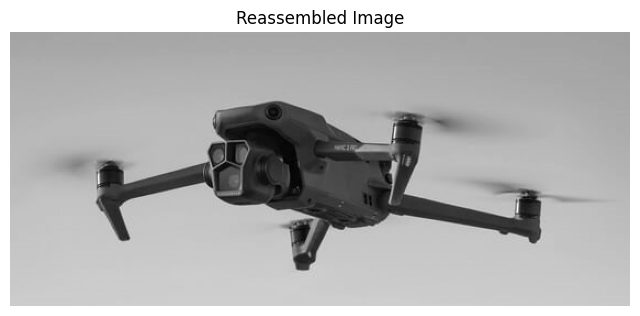

In [25]:
plt.figure(figsize=(8, 8))
plt.imshow(np.array(reassembled_img, dtype=np.uint8), cmap='gray')
plt.title("Reassembled Image")
plt.axis('off')
plt.show()

# Testing

  * Compare your `reassembled_img` with `scene_img_bw`
  * Use scikit-image library's Structural Similarity Index (SSIM) to compare
    * Read https://scikit-image.org/docs/stable/api/skimage.metrics#skimage.metrics.structural_similarity for more info

In [26]:
# This function compares scene_img_bw and reassembled_img to check for correctness in re-assembling

from skimage.metrics import structural_similarity

def check_reassembly(prod=reassembled_img, orig=scene_img_bw):

  # Use scikit-image library's Structural Similarity Index (SSIM) to compare
  # Read https://scikit-image.org/docs/stable/api/skimage.metrics#skimage.metrics.structural_similarity for more info

  score = structural_similarity(reassembled_img, scene_img_bw)


  return score

In [27]:
# You may test your reassembled_img's similarity to the original scene_img_bw

print(check_reassembly(reassembled_img, scene_img_bw))

1.0


Since the image is being recompared to the original image, a perfect score is expected, if it were to be compared with a similar image instead of the exact same, a realistic similarity score would be obtained.

### Testing on other Sample Images

In [28]:
# sample_1, sample_2 = r"./anime-girl.jpg", r"./something.png"
sample_1 = "https://raw.githubusercontent.com/officialar33b/COE-512-Ass1/main/something.png"
sample_2 = "https://raw.githubusercontent.com/officialar33b/COE-512-Ass1/main/anime-girl.jpg"

In [29]:
scene_img1 = cv2.imdecode(
    np.frombuffer(requests.get(sample_1).content, np.uint8), 
    cv2.IMREAD_COLOR
)

scene_img2 = cv2.imdecode(
    np.frombuffer(requests.get(sample_2).content, np.uint8), 
    cv2.IMREAD_COLOR
)

In [30]:
scene_img1_bw = cv2.cvtColor(scene_img1, cv2.COLOR_BGR2GRAY)
scene_img2_bw = cv2.cvtColor(scene_img2, cv2.COLOR_BGR2GRAY)

sample1_list = slice_and_shuffle(scene_img1_bw)
sample2_list = slice_and_shuffle(scene_img2_bw)

## Display the sample images.

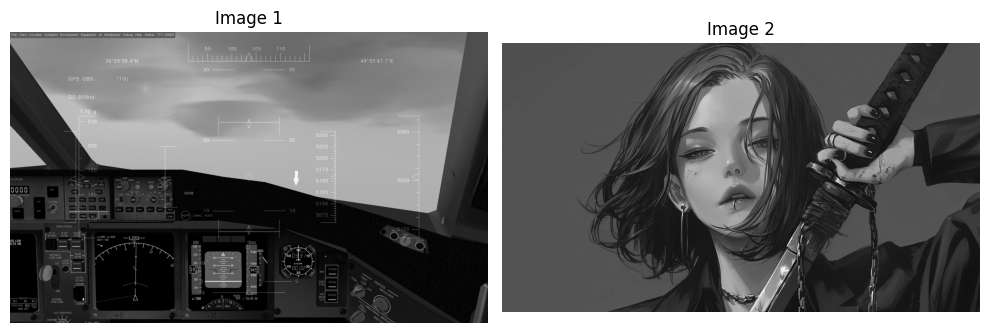

In [31]:
# scene_img_bw = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)
# plt.imshow(scene_img_bw, cmap='gray')


fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(scene_img1_bw, cmap='gray')
ax[0].set_title('Image 1')
ax[0].axis('off')  # Optional: hides tick marks and borders

ax[1].imshow(scene_img2_bw, cmap='gray')
ax[1].set_title('Image 2')
ax[1].axis('off')

plt.tight_layout()
plt.show()

Reassembled Images

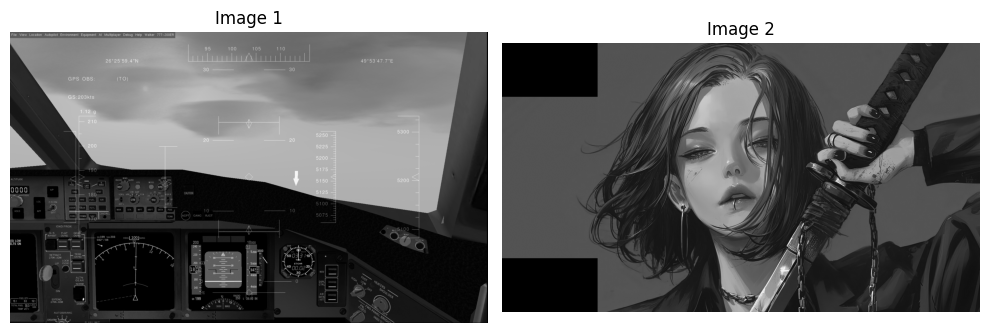

In [32]:
reassembled_sample1 = reassemble_slices(sample1_list, scene_img1_bw)
reassembled_sample2 = reassemble_slices(sample2_list, scene_img2_bw)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(reassembled_sample1, cmap='gray')
ax[0].set_title('Image 1')
ax[0].axis('off')  # Optional: hides tick marks and borders

ax[1].imshow(reassembled_sample2, cmap='gray')
ax[1].set_title('Image 2')
ax[1].axis('off')

plt.tight_layout()
plt.show()

### Similarity Score

In [33]:
# You may test your reassembled_img's similarity to the original scene_img_bw

print("Similarity Score for Sample 1 Image: ",check_reassembly(reassembled_sample1, scene_img1_bw))
print("Similarity Score for Sample 2 Image: ",check_reassembly(reassembled_sample2, scene_img2_bw))

Similarity Score for Sample 1 Image:  1.0
Similarity Score for Sample 2 Image:  1.0


great!